# Inspection of The Results

After all the experiments were ran, it is time to inspect and analyze the outcome. There will be the following parts to that:
1. General inspection of constraint properties, excluding coverage and regularity. The subjects of the inspection will be 1) the distribution of the constraints by the type of linguistic information they employ; 2) the distribution of the types of the application item of the constraints.
2. General inspection of the coverage and regularity measures. At this step, the obtained values will be inspected, which includes the analysis of their distribution and correlation.
3. Inspection of item against type regularity values. This inspection gives an idea about the presence of negative outliers within covered items of the constraints.
4. Inspection of the extent to which the claims about the constraints made in the literature are supported by the data. That includes manual comparison of the quantifiers specified in the constraint definitions ("regularly", "mostly" etc.) and the obtained item regularity values. We concentrate on the item variant since we want a more balanced estimation not affected by productive outliers.

## 1. General Inspection of Constraint Properties

Our goal for this step of inspection is to retrieve the following:
1. The distribution of the constraints by the type of linguistic information they employ.
2. The distribution of the application items of the constraints.

Both properties are retrievable directly from the [master constraints file](../constraints.yaml) so we load and access it here.

In [1]:
import os
import pandas as pd
import yaml
from collections import defaultdict

In [2]:
with open("../../constraints/constraints.yaml", encoding="utf-8") as f:
    constraints: dict = list(yaml.safe_load_all(f))[-1]["constraints"]

### 1.1. Distribution of Constraints by Linguistic Information Type

Beside the linguistic info type, we will also distinguish between the application type (P2l/L2P).

In [5]:
pt1_dir = "../../../resources/custom/compounding/constraint_statistics/"

In [6]:
ling_type_data = {
    "p2l": defaultdict(int),
    "l2p": defaultdict(int)
}

for c_id, constraint in constraints.items():
    if c_id == "def-0": # disregard the default constraint
        continue
    ling_type = sorted(constraint["ling_info_type"])    # sort for multiple types
    ling_type_str = "+".join(ling_type)
    appl_type = c_id.split(":")[0]
    ling_type_data[appl_type][ling_type_str] += 1

ling_type_df = pd.DataFrame(
    data=ling_type_data
).fillna(0).astype(int).sort_index()

ling_type_df.to_csv(
    os.path.join(pt1_dir, "ling_type_df.tsv"),
    sep="\t",
    index=True,
    header=True
)
ling_type_df

,p2l,l2p
derivational,9,2
derivational+morphological,0,1
derivational+morphological+phonological,1,0
derivational+semantic,2,0
lexical,1,4
lexical+morphological,0,1
lexical+morphological+phonological+semantic,0,1
lexical+semantic,1,0
morphological,7,6
morphological+phonological,1,1


### 1.2. Distribution of Constraint Application Items

In [7]:
import matplotlib.pyplot as plt
from collections import Counter

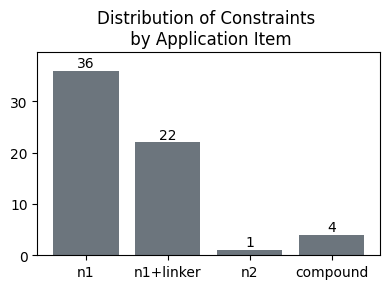

In [8]:
appl_items = [c["appl_item"] for c in constraints.values()]
order = ["n1", "n1+linker", "n2", "compound"]
counts = Counter(appl_items)
values = [counts[k] for k in order]

plt.figure(figsize=(4, 3))

bars = plt.bar(order, values, color="#6c757d")

# add count labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(values) * 0.02,
        f"{int(height)}",
        ha="center"
    )

# add headroom so labels don't collide with top border
plt.ylim(0, max(values) * 1.1)
plt.title("Distribution of Constraints \n by Application Item")
plt.tight_layout()

plt.savefig(
    os.path.join(pt1_dir, "appl_item_distr.png"),
    dpi=800
)
plt.show()

Additionally, we want to know which number of possible items each type has. For that, we need to access GeCoDB_v06.

In [9]:
gecodb_v06_path = "../../../resources/custom/compounding/intermediate_data/gecodb_v06.tsv"

gecodb_v06 = pd.read_csv(
    gecodb_v06_path,
    sep="\t",
    dtype=str,
    header=0,
    index_col="comp_gecodb"
)

In [9]:
gecodb_v06.head()

,comp_lemma,comp_freq,n1_lemma,n1_freq,n1_prod,n1_mass_freq,n2_lemma,n2_freq
comp_gecodb,,,,,,,,
land_kreis,Landkreis,2038715,land,8929250,1175,8243384,kreis,2731589
land_+es_regierung,Landesregierung,777779,land,8929250,1175,8243384,regierung,2648830
land_gericht,Landgericht,576177,land,8929250,1175,8243384,gericht,1784349
land_wirt,Landwirt,457461,land,8929250,1175,8243384,wirt,157625
land_+es_verband,Landesverband,210578,land,8929250,1175,8243384,verband,1138891


In [10]:
appl_item_counts = pd.Series(
    {
        "n1": len(gecodb_v06["n1_lemma"].unique()),
        "n1+linker": len((gecodb_v06["n1_lemma"] + gecodb_v06.index.to_frame()["comp_gecodb"].apply(
            lambda g: "_" if len(gs := g.split("_")) == 2 else gs[1]
        )).unique()),
        "n2": len(gecodb_v06["n2_lemma"].unique()),
        "compound": len(gecodb_v06)
    }
)

appl_item_counts.to_csv(
    os.path.join(pt1_dir, "appl_item_counts.tsv"),
    sep="\t",
    index=True,
    header=False
)
appl_item_counts

n1             3613
n1+linker      4868
n2             7210
compound     282767
dtype: int64

## 2. General Inspection of The Coverage and Regularity Measures

Here, we load the general applicability statistics table and retrieve three things:
1. Scatter plots of coverage against regularity in two variants each (item, type).
    * A shared plot.
    * P2L vs L2P (in this iteration, effectively n1 vs n1+linker).
2. Central tendency measures of the distributions (shared, P2L, L2P).
3. Qualitative analysis of the values clusters.

### 2.1. Draw Scatter Plot

In [11]:
pt2_dir = "../../../resources/custom/compounding/applicability_statistics"

In [13]:
stats = pd.read_csv(
    os.path.join(pt2_dir, "constr_statistics.tsv"),
    sep="\t",
    index_col=0,
    header=0
).dropna()  # remove non-implemented constraints

stats

,n_appl_items,quantifier,cvg_item,cvg_type,reg_item,reg_type
constr_id,,,,,,
def-0,282767.0,majority,1.000,1.000,0.578,0.578
p2l:decl_cl:pl:#0-0|def-0,3614.0,almost regularly,0.148,0.123,0.953,0.908
p2l:decl_cl:pl:#s-0,3614.0,regularly,0.035,0.033,0.970,0.957
p2l:decl_cl:pl:#e-0|def-0,3614.0,mostly,0.159,0.184,0.762,0.689
p2l:decl_cl:pl:#er-0/er|def-0/er,3614.0,mostly,0.019,0.058,0.833,0.868
p2l:decl_cl:pl:#e_uml-0|def-0,3614.0,mostly,0.080,0.111,0.722,0.756
p2l:decl_cl:pl:#0_uml-0|def-0,3614.0,mostly,0.007,0.016,0.946,0.967
p2l:decl_cl:mixed-0/s/en|def-0/s/en,3614.0,almost always,0.013,0.013,0.997,0.996
p2l:drv:sfx:0_pl_sfx-0,3614.0,regularly,0.071,0.045,0.983,0.968


Now draw the plots. We start with the shared plot.

In [37]:
dot_kw = {
    "facecolors": "none",   # hollow inside
    "edgecolors": "black",  # outline
    "s": 40                 # marker size
}

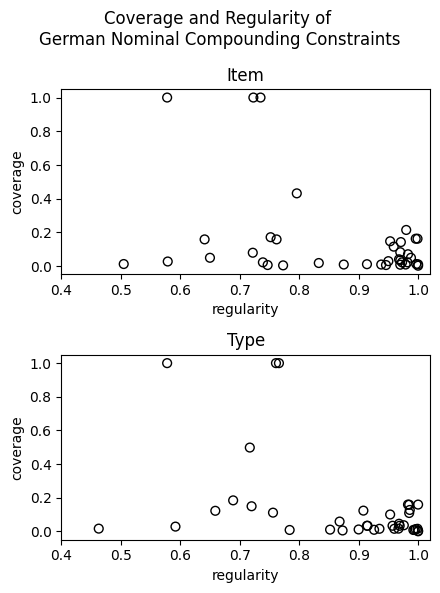

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(4.5, 6))

# first, item cvg/reg values
axes[0].scatter(
    stats["reg_item"],
    stats["cvg_item"],
    **dot_kw
)
axes[0].set_xlabel("regularity")
axes[0].set_ylabel("coverage")
axes[0].set_title("Item")


# first, type cvg/reg values
axes[1].scatter(
    stats["reg_type"],
    stats["cvg_type"],
    **dot_kw
)
axes[1].set_xlabel("regularity")
axes[1].set_ylabel("coverage")
axes[1].set_title("Type")

for ax in axes:
    ax.set_xlim(0.4, 1.02)


fig.suptitle(
    "Coverage and Regularity of \n"
    "German Nominal Compounding Constraints"
)

plt.tight_layout()
plt.savefig(
    os.path.join(pt2_dir, "cov_reg_shared.png"),
    dpi=1200
)
plt.show()

Proceed to the P2L va L2P plot.

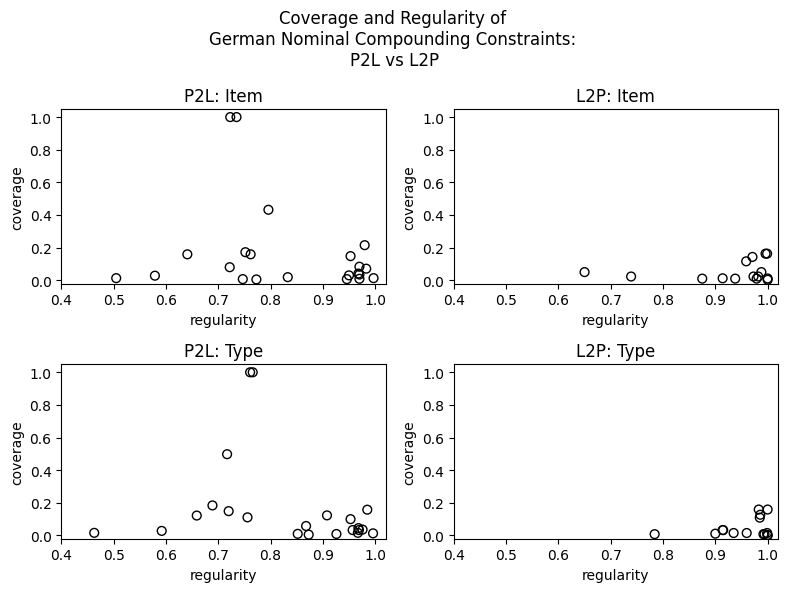

In [92]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

p2l_stats = stats[stats.index.str.startswith("p2l")]
l2p_stats = stats[stats.index.str.startswith("l2p")]

# item P2L
axes[0, 0].scatter(
    p2l_stats["reg_item"],
    p2l_stats["cvg_item"],
    **dot_kw
)
axes[0, 0].set_xlabel("regularity")
axes[0, 0].set_ylabel("coverage")
axes[0, 0].set_title("P2L: Item")


# type P2L
axes[1, 0].scatter(
    p2l_stats["reg_type"],
    p2l_stats["cvg_type"],
    **dot_kw
)
axes[1, 0].set_xlabel("regularity")
axes[1, 0].set_ylabel("coverage")
axes[1, 0].set_title("P2L: Type")


# item L2P
axes[0, 1].scatter(
    l2p_stats["reg_item"],
    l2p_stats["cvg_item"],
    **dot_kw
)
axes[0, 1].set_xlabel("regularity")
axes[0, 1].set_ylabel("coverage")
axes[0, 1].set_title("L2P: Item")


# type L2P
axes[1, 1].scatter(
    l2p_stats["reg_type"],
    l2p_stats["cvg_type"],
    **dot_kw
)
axes[1, 1].set_xlabel("regularity")
axes[1, 1].set_ylabel("coverage")
axes[1, 1].set_title("L2P: Type")


for ax in axes.flatten():
    ax.set_xlim(0.4, 1.02)
    ax.set_ylim(-0.02, 1.05)


fig.suptitle(
    "Coverage and Regularity of \n"
    "German Nominal Compounding Constraints: \n"
    "P2L vs L2P"
)

plt.tight_layout()
plt.savefig(
    os.path.join(pt2_dir, "cov_reg_p2l_l2p.png"),
    dpi=1200
)
plt.show()

### 2.2. Central Tendency Measures

We want to obtain min, max, mean, median, and sd of the values in three variants: shared, P2L, L2P.

In [52]:
def compute_central_tend(series: pd.Series) -> dict:
    return {
        "min": series.min().round(3),
        "max": series.max().round(3),
        "mean": series.mean().round(3),
        "median": series.median().round(3),
        "sd": series.std().round(3)
    }


cent_tend_df = pd.DataFrame(
    {
        # shared
        "shared: cvg_item": compute_central_tend(stats["cvg_item"]),
        "shared: cvg_type": compute_central_tend(stats["cvg_type"]),
        "shared: reg_item": compute_central_tend(stats["reg_item"]),
        "shared: reg_type": compute_central_tend(stats["reg_type"]),
        # p2l
        "p2l: cvg_item": compute_central_tend(p2l_stats["cvg_item"]),
        "p2l: cvg_type": compute_central_tend(p2l_stats["cvg_type"]),
        "p2l: reg_item": compute_central_tend(p2l_stats["reg_item"]),
        "p2l: reg_type": compute_central_tend(p2l_stats["reg_type"]),
        # l2p
        "l2p: cvg_item": compute_central_tend(l2p_stats["cvg_item"]),
        "l2p: cvg_type": compute_central_tend(l2p_stats["cvg_type"]),
        "l2p: reg_item": compute_central_tend(l2p_stats["reg_item"]),
        "l2p: reg_type": compute_central_tend(l2p_stats["reg_type"])
    }
)

cent_tend_df.to_csv(
    os.path.join(pt2_dir, "cov_reg_central_tend.tsv"),
    sep="\t",
    index=True,
    header=True
)
cent_tend_df

,shared: cvg_item,shared: cvg_type,shared: reg_item,shared: reg_type,p2l: cvg_item,p2l: cvg_type,p2l: reg_item,p2l: reg_type,l2p: cvg_item,l2p: cvg_type,l2p: reg_item,l2p: reg_type
min,0.003,0.000,0.505,0.463,0.005,0.005,0.505,0.463,0.003,0.000,0.650,0.784
max,1.000,1.000,1.000,1.000,1.000,1.000,0.997,0.996,0.163,0.159,1.000,1.000
mean,0.146,0.143,0.863,0.875,0.169,0.170,0.830,0.833,0.054,0.047,0.931,0.956
median,0.038,0.033,0.948,0.931,0.056,0.052,0.814,0.870,0.023,0.015,0.973,0.985
sd,0.267,0.270,0.145,0.141,0.287,0.289,0.147,0.148,0.060,0.059,0.104,0.059


### 2.3. Qualitative Analysis of Value Clusters

Now, we check the numbers of different groups of constraints by their coverage and regularity. The groups are chosen by a visual inspection of the plot; the choice aims at a more illustrative representation of the results.

* Many of the coverage values are concentrated in the bottom of the plots so we explore values under 0.2, 0.05, and 0.015.
* There is a slight shift of regularity towards 1.0 so we group values over 0.9 and 0.98.

Many of the coverage values are concentrated in the bottom of the plots.

In [53]:
def measure_value_clusters(stats: pd.DataFrame) -> dict:
    return {
        "cvg_under_0.2": stats[
            (stats["cvg_item"] < 0.2)
            & (stats["cvg_type"] < 0.2)
        ].shape[0],
        "cvg_under_0.05": stats[
            (stats["cvg_item"] < 0.05)
            & (stats["cvg_type"] < 0.05)
        ].shape[0],
        "cvg_under_0.015": stats[
            (stats["cvg_item"] < 0.015)
            & (stats["cvg_type"] < 0.015)
        ].shape[0],
        "reg_over_0.9": stats[
            (stats["reg_item"] > 0.9)
            & (stats["reg_type"] > 0.9)
        ].shape[0],
        "reg_over_0.98": stats[
            (stats["reg_item"] > 0.98)
            & (stats["reg_type"] > 0.98)
        ].shape[0]
    }

val_cluster_df = pd.DataFrame(
    {
        "shared": measure_value_clusters(stats),
        "p2l": measure_value_clusters(p2l_stats),
        "l2p": measure_value_clusters(l2p_stats)
    }
)

val_cluster_df.to_csv(
    os.path.join(pt2_dir, "cov_reg_val_clusters.tsv"),
    sep="\t",
    index=True,
    header=True
)
val_cluster_df

,shared,p2l,l2p
cvg_under_0.2,33,18,15
cvg_under_0.05,19,10,9
cvg_under_0.015,7,4,3
reg_over_0.9,20,9,11
reg_over_0.98,6,1,5


## 3. Inspection of Item Against Type Regularity Values

We will not consider the difference between item coverage values because they effectively approximate the distribution of N1 productivity that has already been extensively researched in the literature. Instead, we will concentrate on (qualitative) estimation of the productivity of _negative outliers_ within item groups of the constraints. By _negative outliers_, we mean items that build compounds that actively violate a given constraint. With this regard, we distinguish 3 cases:
* item reg >> type reg. A considerable share of the _negative outliers_ have a high average productivity so these negative outliers build a considerable part of the covered compounds. Example: all 414 compounds that do not conform to `p2l:drv:deadj_schwa$-0/en` (which amounts to almost 15% of all 2798 covered compounds) are constituted by a single item, which results in regs of `0.97` vs `0.852`.
* item reg << type reg. Most of the _negative outliers_ have a low average productivity. Items that do conform to the constraint build the majority of the covered compounds. Example: the 1517 compounds covered by `p2l:drv:sfx:e_pl_sfx-0` are constituted by 27 items. However, all 193 deviating compounds (only ~13% of all) are constituted by 10 items which makes for 37% of all covered items, which results in regs of `0.747` vs `0.873`.
* item reg ~~ type reg. Most of the  _negative outliers_ have a moderate average productivity. They produce a share of compounds comparable to their share of all covered items. Example: 128 (1.4% of covered 9410) compounds that deviate from `p2l:decl_cl:pl:#s-0` are constituted by 6 (1.5% out of 406 covered) items.

### 3.1. MAE Between Item and Type Values

LEGACY

Here, we want to investigate how large the gap between the item and the type values for the same constraint is on average.

In [111]:
from sklearn.metrics import mean_absolute_error

In [112]:
def compute_maes(d1: pd.Series, d2: pd.Series) -> dict:
    return round(mean_absolute_error(d1, d2), 3)

item_type_maes = pd.DataFrame(
    {
        "shared": {
            "cvg": compute_maes(stats["cvg_item"], stats["cvg_type"]),
            "reg": compute_maes(stats["reg_item"], stats["reg_type"])
        },
        "p2l": {
            "cvg": compute_maes(p2l_stats["cvg_item"], p2l_stats["cvg_type"]),
            "reg": compute_maes(p2l_stats["reg_item"], p2l_stats["reg_type"])
        },
        "l2p": {
            "cvg": compute_maes(l2p_stats["cvg_item"], l2p_stats["cvg_type"]),
            "reg": compute_maes(l2p_stats["reg_item"], l2p_stats["reg_type"])
        }
    }
)

item_type_maes.to_csv(
    os.path.join(pt2_dir, "item_type_maes.tsv"),
    sep="\t",
    index=True,
    header=True
)
item_type_maes

,shared,p2l,l2p
cvg,0.013,0.017,0.009
reg,0.040,0.043,0.039


### 3.2. Estimation of Negative Outlier Productivity

In [113]:
reg_item_type_df = pd.DataFrame(
    {
        "reg_item": stats["reg_item"],
        "reg_type": stats["reg_type"],
        "diff": (
            (stats["reg_type"] - stats["reg_item"])
            / (stats["reg_type"] + 0.0001)
        ).round(3)
    }
)

reg_item_type_df

,reg_item,reg_type,diff
constr_id,,,
def-0,0.578,0.578,0.000
p2l:decl_cl:pl:#0-0|def-0,0.953,0.908,-0.050
p2l:decl_cl:pl:#s-0,0.970,0.957,-0.014
p2l:decl_cl:pl:#e-0|def-0,0.762,0.689,-0.106
p2l:decl_cl:pl:#er-0/er|def-0/er,0.833,0.868,0.040
p2l:decl_cl:pl:#e_uml-0|def-0,0.722,0.756,0.045
p2l:decl_cl:pl:#0_uml-0|def-0,0.946,0.967,0.022
p2l:decl_cl:mixed-0/s/en|def-0/s/en,0.997,0.996,-0.001
p2l:drv:sfx:0_pl_sfx-0,0.983,0.968,-0.015


In [117]:
df = pd.read_csv(
    # the file needs to be extracted from zip
    os.path.join(pt2_dir, "appl_index.tsv"),
    sep="\t",
    index_col=0,
    header=0
)

/var/folders/_8/wwb5csy9605g6rl6wf4lcfch0000gr/T/ipykernel_4583/3911824271.py:1: DtypeWarning: Columns (6,9,12,21,36,42,48,54,57,60,66,69,75,81,84,87,90,93,96,123,126,129,132,135,138,141,150,153,156,162,165,168,174,180,186) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [190]:
def compute_shares(c_id: str) -> pd.DataFrame:
    subdf = df[df[c_id + "_is_applicable"]][[
        c_id + "_item",
        c_id + "_applies"
    ]]
    neg_subdf = subdf[subdf[c_id + "_applies"] == False]

    items = subdf[c_id + "_item"].unique()
    neg_items = neg_subdf[c_id + "_item"].unique()
    
    avg_item_prod = len(subdf) / len(items)
    above_avg_prod = []
    below_avg_prod = []
    for item in neg_items:
        bw_item = neg_subdf[neg_subdf[c_id + "_item"] == item]
        prop = len(bw_item) / avg_item_prod
        if prop >= 1.5:
            above_avg_prod.append(len(bw_item))
        elif prop < 2/3:
            below_avg_prod.append(len(bw_item))

    shares_df = pd.DataFrame(
        {
            "n_comp": {
                "all": len(subdf),
                "neg": len(neg_subdf)
            },
            "n_items": {
                "all": len(items),
                "neg": len(neg_items)
            }
        }
    )

    shares_df["avg_prod"] = (
        shares_df["n_comp"] / shares_df["n_items"]
    ).round(3)

    shares_df["n_above_avg_prod"] = [None, len(above_avg_prod)]
    shares_df["n_below_avg_prod"] = [None, len(below_avg_prod)]
    shares_df["avg_above_avg_prod"] = [None, pd.array(above_avg_prod).mean()]
    shares_df["avg_below_avg_prod"] = [None, pd.array(below_avg_prod).mean()]

    shares_df = shares_df.T

    return shares_df

In [179]:
# case 1: item reg >> type reg
case1_df = reg_item_type_df[reg_item_type_df["diff"] < -0.1]
case1_ids = case1_df.index.tolist()
case1_df

,reg_item,reg_type,diff
constr_id,,,
p2l:decl_cl:pl:#e-0|def-0,0.762,0.689,-0.106
p2l:drv:deadj_schwa$-0/en,0.970,0.852,-0.138
p2l:tend:sonority-!s,0.796,0.717,-0.110


In [191]:
compute_shares(case1_ids[0])

,all,neg
n_comp,52080.000,16191.000000
n_items,574.000,262.000000
avg_prod,90.732,61.798000
n_above_avg_prod,NaN,43.000000
n_below_avg_prod,NaN,190.000000
avg_above_avg_prod,NaN,254.581395
avg_below_avg_prod,NaN,13.800000


In [192]:
compute_shares(case1_ids[1])

,all,neg
n_comp,2798,414
n_items,32,1
avg_prod,87.438,414.0
n_above_avg_prod,NaN,1.0
n_below_avg_prod,NaN,0.0
avg_above_avg_prod,NaN,414.0
avg_below_avg_prod,None,<NA>


In [193]:
compute_shares(case1_ids[2])

,all,neg
n_comp,140839.000,39867.000000
n_items,1560.000,461.000000
avg_prod,90.281,86.479000
n_above_avg_prod,NaN,84.000000
n_below_avg_prod,NaN,315.000000
avg_above_avg_prod,NaN,345.023810
avg_below_avg_prod,NaN,16.860317


In [194]:
# case 1: item reg << type reg
case2_df = reg_item_type_df[reg_item_type_df["diff"] > 0.1]
case2_ids = case2_df.index.tolist()
case2_df

,reg_item,reg_type,diff
constr_id,,,
p2l:drv:sfx:e_pl_sfx-0,0.747,0.873,0.144
p2l:drv:sfx:deverb_#en$-s,0.773,0.926,0.165
l2p:s|smpx_high_freq,0.650,0.914,0.289


In [195]:
compute_shares(case2_ids[0])

,all,neg
n_comp,1517,193
n_items,27,10
avg_prod,56.185,19.3
n_above_avg_prod,NaN,0.0
n_below_avg_prod,NaN,8.0
avg_above_avg_prod,None,<NA>
avg_below_avg_prod,NaN,12.75


In [196]:
compute_shares(case2_ids[1])

,all,neg
n_comp,2518,186
n_items,19,14
avg_prod,132.526,13.286
n_above_avg_prod,NaN,0.0
n_below_avg_prod,NaN,14.0
avg_above_avg_prod,None,<NA>
avg_below_avg_prod,NaN,13.285714


In [197]:
compute_shares(case2_ids[2])

,all,neg
n_comp,9192.000,789.000000
n_items,243.000,85.000000
avg_prod,37.827,9.282000
n_above_avg_prod,NaN,3.000000
n_below_avg_prod,NaN,76.000000
avg_above_avg_prod,NaN,90.666667
avg_below_avg_prod,NaN,3.815789


In [201]:
# case 3: item reg ~~ type reg
case3_df = reg_item_type_df[
    (reg_item_type_df["diff"] >= -0.1)
    & (reg_item_type_df["diff"] <= 0.1)
]
case3_ids = case3_df.index.tolist()
case3_df

,reg_item,reg_type,diff
constr_id,,,
def-0,0.578,0.578,0.000
p2l:decl_cl:pl:#0-0|def-0,0.953,0.908,-0.050
p2l:decl_cl:pl:#s-0,0.970,0.957,-0.014
p2l:decl_cl:pl:#er-0/er|def-0/er,0.833,0.868,0.040
p2l:decl_cl:pl:#e_uml-0|def-0,0.722,0.756,0.045
p2l:decl_cl:pl:#0_uml-0|def-0,0.946,0.967,0.022
p2l:decl_cl:mixed-0/s/en|def-0/s/en,0.997,0.996,-0.001
p2l:drv:sfx:0_pl_sfx-0,0.983,0.968,-0.015
p2l:drv:deverb_schwa$-0|def-0,0.579,0.592,0.022


In [207]:
compute_shares(case3_ids[5])

,all,neg
n_comp,4509,147
n_items,25,19
avg_prod,180.36,7.737
n_above_avg_prod,NaN,0.0
n_below_avg_prod,NaN,19.0
avg_above_avg_prod,None,<NA>
avg_below_avg_prod,NaN,7.736842


## 4. Inspection of The Extent to Which the Claims About the Constraints Made in The Literature Are Supported by The Data

The following steps are to be done for final inspection:
1. Manually inspect the support level of the claims in the empirical data. For each (analyzed) constraint, record the level of support. Since the definitions are mostly vague, base the decision on commonsense judgments. For the support level, we concentrate on the type variant of the measures since we focus on the linguistic side of the question (not real usage). There are 4 levels of support:
    * Supported. Full or very close correspondence between the quantifier and the empirical data. Examples: "regular" vs 0.99, "mostly" vs 0.75.
    * Partially supported. The gap is not critical yet noticeable. Examples: "regular" vs 0.93, "tends" vs 0.6, "sometimes" vs 0.9.
    * Not supported. The discrepancy between the quantifier and the empirical data is too significant to ignore. Examples: "regular" vs 0.85, "tends" vs 0.4.
    * NA: no data available (unreliable or semantic/lexical constraints).

Note: this steps is being conducted in the file with constraints definitions, see `compounding/constraints/constraints.yaml`. While it is being now made at the time of this inspection, we cannot reflect this processes here. After this step is done, we pull the results from this file and further inspect them in detail, specifically:

2. Inspect the distribution of the support levels.
3. Manually inspect the constraints that are only partially supported by the data or not supported at all.

### 4.1. Inspection of The Support Level

Done separately in `compounding/constraints/constraints.yaml`.

### 4.2. Inspection of Support Level Distribution

Now, we read the constraint definition file for inspection.

In [ ]:
def inspect_constr_appl(c_id: str, counterex: bool=True):
    subdf = df[df[c_id + "_is_applicable"]][[
        c_id + "_item",
        c_id + "_applies"
    ]]
    if counterex:
        subdf = subdf[subdf[c_id + "_applies"] == False]
        subdf = subdf[[c_id + "_item"]]   # applies always False
    items = subdf[c_id + "_item"].unique()
    example_dfs = []
    for item in items:
        items_subdf = subdf[subdf[c_id + "_item"] == item]
        l = len(items_subdf)
        m = min(l, 3)
        examples = items_subdf.sample(m)
        examples.insert(1, "n_bw_item", [l] * m)
        example_dfs.append(examples)
    examples_subdf = pd.concat(example_dfs, axis=0)
    examples_subdf.sort_values(by="n_bw_item", inplace=True, ascending=False)
    return subdf, examples_subdf

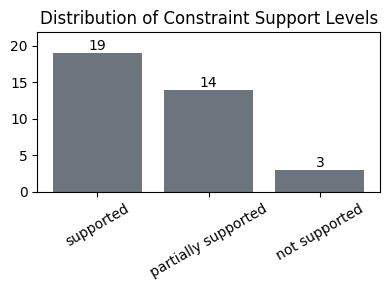

In [ ]:
sup_levels = {
    c_id: sl for c_id, c in constraints.items()
    if (sl := c["support_level"]) != "NA"
}
order = ["supported", "partially supported", "not supported"] #, "NA"]
counts = Counter(sup_levels.values())
values = [counts[k] for k in order]

plt.figure(figsize=(4, 3))

bars = plt.bar(order, values, color="#6c757d")

# add count labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(values) * 0.02,
        f"{int(height)}",
        ha="center"
    )

# add headroom so labels don't collide with top border
plt.ylim(0, max(values) * 1.15)
plt.title("Distribution of Constraint Support Levels")
plt.xticks(rotation=30, ha="center")
plt.tight_layout()

plt.savefig(
    os.path.join(pt1_dir, "sup_level_distr.png"),
    dpi=800
)
plt.show()

### 4.3. Inspection of Partially / Not Supported Constraints

In [94]:
part_sup_ids = [
    c_id for c_id, sl in sup_levels.items()
    if sl == "partially supported"
]

part_sup_ids






part_sup_ids = [
    "p2l:decl_cl:pl:#s-0",
    "p2l:drv:sfx:e_pl_sfx-0",
    "p2l:drv:sfx:deverb_#en$-s",
    "p2l:phon_fin:vow$-0",
    "p2l:phon_fin:schwa$-en",
    "l2p:n",
    "l2p:en|par",
    "l2p:e|#stressed_syl",
    "l2p:er|#stressed_syl",
    "l2p:es|mono_syl"
]

In [82]:
c_id = part_sup_ids[0]
subdf, examples_subdf = inspect_constr_appl(c_id)
examples_subdf

,p2l:decl_cl:pl:#s-0_item,n_bw_item
comp_gecodb,,
karneval_+s_empfang,karneval,194
karneval_+s_geschäft,karneval,194
karneval_+s_kostüm,karneval,194
fasching_+s_gag,fasching,129
fasching_+s_beginn,fasching,129
fasching_+s_jahr,fasching,129
interim_+s_direktor,interim,64
interim_+s_abkommen,interim,64
interim_+s_titel,interim,64


In [83]:
c_id = part_sup_ids[1]
subdf, examples_subdf = inspect_constr_appl(c_id)
examples_subdf

,p2l:drv:sfx:e_pl_sfx-0_item,n_bw_item
comp_gecodb,,
internat_+s_ausbildung,internat,52
internat_+s_direktor,internat,52
internat_+s_schülerin,internat,52
dekanat_+s_versammlung,dekanat,39
dekanat_+s_jugend,dekanat,39
dekanat_+s_besuch,dekanat,39
magistrat_+s_zimmer,magistrat,31
magistrat_+s_gericht,magistrat,31
magistrat_+s_abteilung,magistrat,31


In [84]:
c_id = part_sup_ids[2]
subdf, examples_subdf = inspect_constr_appl(c_id)
examples_subdf

,p2l:drv:sfx:deverb_#en$-s_item,n_bw_item
comp_gecodb,,
essen_versorger,essen,42
essen_gast,essen,42
essen_zeit,essen,42
leben_raum,leben,26
leben_gefahr,leben,26
leben_sorte,leben,26
braten_spieß,braten,26
braten_saft,braten,26
braten_gabel,braten,26


In [85]:
c_id = part_sup_ids[3]
subdf, examples_subdf = inspect_constr_appl(c_id)
examples_subdf

,p2l:phon_fin:vow$-0_item,n_bw_item
comp_gecodb,,
idee_+n_tag,idee,118
idee_+n_fänger,idee,118
idee_+n_fang,idee,118
fee_+n_gestalt,fee,39
fee_+n_könig,fee,39
fee_+n_gold,fee,39
kalorie_+n_bomber,kalorie,36
kalorie_+n_ersparnis,kalorie,36
kalorie_+n_konto,kalorie,36


In [86]:
c_id = part_sup_ids[4]
subdf, examples_subdf = inspect_constr_appl(c_id)
examples_subdf

,p2l:phon_fin:schwa$-en_item,n_bw_item
comp_gecodb,,
reise_entscheidung,reise,510
reise_besprechung,reise,510
reise_redakteurin,reise,510
liebe_+s_welt,liebe,434
liebe_+s_song,liebe,434
...,...,...
funke_lauge,funke,1
rinde_rohr,rinde,1
länge_feld,länge,1


In [87]:
c_id = part_sup_ids[5]
subdf, examples_subdf = inspect_constr_appl(c_id)
examples_subdf

,l2p:n_item,n_bw_item
comp_gecodb,,
oper_+n_bereich,oper_+n_,262
oper_+n_cafe,oper_+n_,262
oper_+n_krieg,oper_+n_,262
schwester_+n_paar,schwester_+n_,50
schwester_+n_gruppe,schwester_+n_,50
schwester_+n_gemeinschaft,schwester_+n_,50
nummer_+n_eingabe,nummer_+n_,35
nummer_+n_mitnahme,nummer_+n_,35
nummer_+n_feld,nummer_+n_,35


In [88]:
c_id = part_sup_ids[6]
subdf, examples_subdf = inspect_constr_appl(c_id)
examples_subdf

,l2p:en|par_item,n_bw_item
comp_gecodb,,
stern_+en_dieb,stern_+en_,197
stern_+en_kreuz,stern_+en_,197
stern_+en_wind,stern_+en_,197
instrument_+en_kammer,instrument_+en_,97
instrument_+en_teil,instrument_+en_,97
instrument_+en_stimme,instrument_+en_,97
storch_+en_art,storch_+en_,90
storch_+en_gemeinschaft,storch_+en_,90
storch_+en_zählung,storch_+en_,90


In [92]:
c_id = part_sup_ids[7]
subdf, examples_subdf = inspect_constr_appl(c_id)
examples_subdf

,l2p:e|#stressed_syl_item,n_bw_item
comp_gecodb,,
anhalt_+e_kelle,anhalt_+e_,15
anhalt_+e_posten,anhalt_+e_,15
anhalt_+e_stab,anhalt_+e_,15
inhalt_+e_geschäft,inhalt_+e_,3
inhalt_+e_angebot,inhalt_+e_,3
inhalt_+e_produktion,inhalt_+e_,3
vorjahr_+e_sieger,vorjahr_+e_,1


In [95]:
c_id = part_sup_ids[8]
subdf, examples_subdf = inspect_constr_appl(c_id)
examples_subdf

,l2p:er|#stressed_syl_item,n_bw_item
comp_gecodb,,
mitglied_+=er_preis,mitglied_+=er_,163
mitglied_+=er_kauf,mitglied_+=er_,163
mitglied_+=er_betreuung,mitglied_+=er_,163
altertum_+=er_verwaltung,altertum_+=er_,3
altertum_+=er_behörde,altertum_+=er_,3
altertum_+=er_sammlung,altertum_+=er_,3
vorbild_+=er_sammlung,vorbild_+=er_,1


In [96]:
c_id = part_sup_ids[9]
subdf, examples_subdf = inspect_constr_appl(c_id)
examples_subdf

,l2p:es|mono_syl_item,n_bw_item
comp_gecodb,,
gesetz_+es_forderung,gesetz_+es_,179
gesetz_+es_bündel,gesetz_+es_,179
gesetz_+es_ebene,gesetz_+es_,179
vorjahr_+es_prinzessin,vorjahr_+es_,108
vorjahr_+es_marke,vorjahr_+es_,108
vorjahr_+es_bestand,vorjahr_+es_,108
vortag_+es_schluss,vortag_+es_,11
vortag_+es_sieger,vortag_+es_,11
vortag_+es_erfolg,vortag_+es_,11
